In [76]:
from feos import *
import si_units as si
import numpy as np
import pandas as pd
from si_units import *
import matplotlib.pyplot as plt

import seaborn as sns
sns.set_context('poster')
sns.set_palette('Dark2')
sns.set_style('ticks')
colors = sns.palettes.color_palette('Dark2', 8)

## Compare SAFT-VRQ-Mie and $uv$-CS-theory for Helium

In [77]:
tc = 5.1953
vle = pd.read_csv("data/helium_data/nist_vle.txt", sep="\t")
vle = vle[vle['Temperature (K)'] < 0.9 * tc][11:]
isotherms = pd.read_csv("data/helium_data/nist_isotherms.txt", sep="\t")

In [109]:
# SAFT-VRQ-Mie
ailo = dict(sigma=2.7443, epsilon_k=5.4195, rep=9, att=6, c_sigma=[1.0]*3, c_epsilon_k=[1.0]*3, c_rep=[1.0]*5)
vrqmie_ailo = dict(m=1.0, sigma=2.7443, epsilon_k=5.4195, lr=9, la=6, fh=1)
vrq_pr = PureRecord(identifier=Identifier("helium"), molarweight=4.002602, **vrqmie_ailo)
vrq_model = EquationOfState.saftvrqmie(Parameters.new_pure(vrq_pr))

#vle_vrq = PhaseDiagram.pure(vrq_model, 2.5*KELVIN, 100)
df_vrq = PhaseDiagram.pure(vrq_model, min_temperature=2*si.KELVIN, npoints=250).to_dict(feos.Contributions.Residual)

In [113]:
# uv-CS with optimized parameters
thijs = dict(
    sigma=2.6953,
    epsilon_k=5.2850,
    rep=8.2761,
    att=6.0,
    c_sigma=[4.1529, 17.130, 4.6523],
    c_epsilon_k=[0.25290, 0.0, 0.42998],
    c_rep=[0.88165, 1.0523, 2.7524, 0.97560, 0.82524]
)
pr = feos.PureRecord(identifier=feos.Identifier("helium"), molarweight=4.002602, **thijs)
cs_model = feos.EquationOfState.uvcstheory(feos.Parameters.new_pure(pr))
df_cs = feos.PhaseDiagram.pure(cs_model, min_temperature=2*si.KELVIN, npoints=250).to_dict(feos.Contributions.Residual)

### Reproduce FIG. 4 of J. Chem. Phys. 162, 031101 (2025); doi: 10.1063/5.0243474

In [156]:
isotherms = isotherms.loc[isotherms['Pressure (MPa)'] < 5]

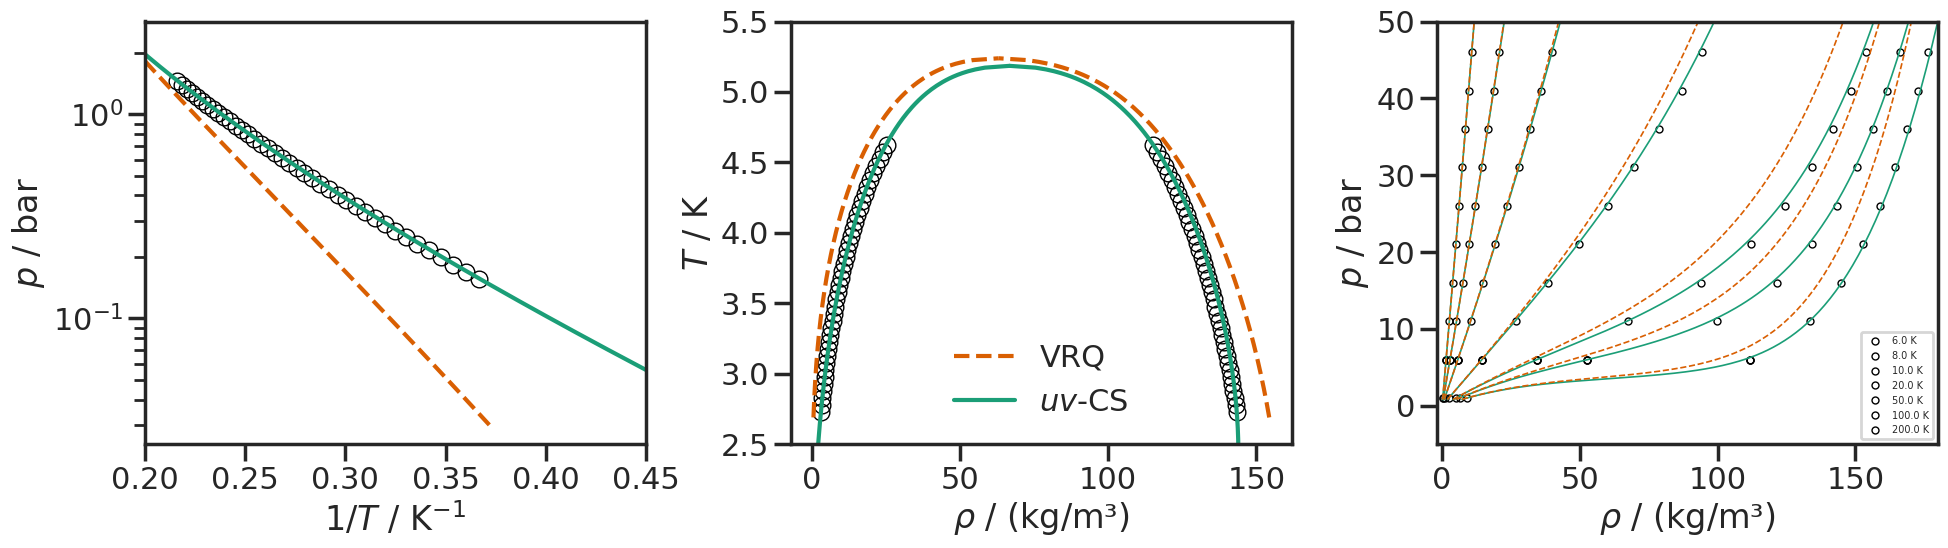

In [176]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- Subplot 1: Vapor pressure vs Temperature  ---
axes[0].plot(1/ vle['Temperature (K)'], vle['Pressure (MPa)'] * (MEGA*PASCAL/BAR), 'o', mec='k', mfc='None')
axes[0].set_xlabel('$1/T$ / K$^{-1}$')
axes[0].set_ylabel('$p$ / bar')
#axes[0].set_title('Vapor Pressure')
axes[0].set_yscale('log')
axes[0].plot(1/np.array(df_vrq["temperature"]), np.array(df_vrq["pressure"]) * (PASCAL/BAR), '--', color=colors[1])
axes[0].plot(1/np.array(df_cs["temperature"]), np.array(df_cs["pressure"]) * (PASCAL/BAR),  color=colors[0])
axes[0].set_xlim(0.2, 0.45)

# --- Subplot 2: Density vs Temperature---
axes[1].plot(vle["Density (l, kg/m3)"], vle['Temperature (K)'], "o", mec='k', mfc='None')
axes[1].plot(vle["Density (v, kg/m3)"], vle['Temperature (K)'], 'o', mec='k', mfc='None')
axes[1].set_xlabel('$\\rho$ / (kg/m³)')
axes[1].set_ylabel('$T$ / K')
axes[1].set_ylim(2.5, 5.5)
axes[1].plot(df_vrq["mass density liquid"], df_vrq["temperature"],'--', color=colors[1], label="VRQ")
axes[1].plot(df_vrq["mass density vapor"], df_vrq["temperature"], '--', color=colors[1] )


axes[1].plot(df_cs["mass density liquid"], df_cs["temperature"],'-', color=colors[0], label="$uv$-CS")
axes[1].plot(df_cs["mass density vapor"], df_cs["temperature"], '-', color=colors[0] )


axes[1].legend(loc='best', frameon=False)

#axes[1].set_title('VLE Envelope')

# --- Subplot 3: Pressure vs Density (isotherms) ---
for temp, group in isotherms.groupby('Temperature (K)'):
    axes[2].plot(group['Density (l, kg/m3)'],np.array( group['Pressure (MPa)']) * (MEGA*PASCAL)/BAR,
                 'o', mec='k', mfc='None', ms=5, label=f'{temp} K')
axes[2].set_xlabel('$\\rho$ / (kg/m³)')
axes[2].set_ylabel('$p$ / bar')
axes[2].legend(fontsize=7, loc='best')
axes[2].set_ylim(-5,50)
axes[2].set_xlim(-2, 180)


# --- Add theory isotherms ---
isotherm_temps = isotherms['Temperature (K)'].unique()

for i, temp in enumerate(sorted(isotherm_temps)):
    color = colors[i % len(colors)]  # cycle through your color list

    rho_min = isotherms[isotherms['Temperature (K)'] == temp]['Density (l, kg/m3)'].min()
    rho_max = isotherms[isotherms['Temperature (K)'] == temp]['Density (l, kg/m3)'].max()
    densities = np.linspace(rho_min * 0.8, rho_max * 1.2, 200)

    pressures = []
    valid_densities = []
    pressures_vrq = []
    for rho in densities:
        try:
            state = feos.State(
                cs_model,
                temperature=temp * si.KELVIN,
                density=(rho / 4.002602) * si.MOL / si.METER**3 * 1000  # kg/m³ → mol/m³
            )
            p = state.pressure(feos.Contributions.Residual) / BAR
            pig = (rho / 4.002602) * si.MOL / si.METER**3 * 1000 * RGAS * temp * KELVIN
            #print(pig / BAR)
            pressures.append(p + pig/BAR)
            
            
            state = feos.State(
                vrq_model,
                temperature=temp * si.KELVIN,
                density=(rho / 4.002602) * si.MOL / si.METER**3 * 1000  # kg/m³ → mol/m³
            )
            p = state.pressure(feos.Contributions.Residual) / BAR
            pressures_vrq.append(p + pig/BAR)
            
            valid_densities.append(rho)
        except Exception:
            continue

    if valid_densities:
        axes[2].plot(valid_densities, pressures, '-',lw=1.2, color=colors[0] )
        axes[2].plot(valid_densities, pressures_vrq, '--',lw=1.2, color=colors[1] )
plt.tight_layout()
plt.show()